# Paper Figures and Tables

Generates figures and tables for the Boomer-Py manuscript from real evaluation data.

- **Brain benchmark**: 72 grid search configs across 6 Allen Brain Atlas ontologies
- **CL+BTO case study**: Cell Ontology + BRENDA Tissue Ontology alignment

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

GRID_DIR = Path("../../analysis/brain/results/grid")
TUTORIAL_DIR = Path("../tutorial/real-world-alignment-files")

## Load grid search evaluation data

In [2]:
# Parameter values from brain-grid.yaml
CLIQUE_VALS = [5, 10, 25]
SOL_VALS = [10, 50, 100, 200]
FILTER_VALS = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95]

rows = []
for i in range(72):
    with open(GRID_DIR / f"evaluation_{i}.json") as f:
        d = json.load(f)
    ci = i // 24
    si = (i % 24) // 6
    fi = i % 6
    tp, fp, fn = d["tp"], d["fp"], d["fn"]
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    rows.append({
        "config": i,
        "max_pfacts_per_clique": CLIQUE_VALS[ci],
        "max_candidate_solutions": SOL_VALS[si],
        "pr_filter": FILTER_VALS[fi],
        "tp": tp, "fp": fp, "fn": fn,
        "precision": p, "recall": r, "f1": f1,
    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} configurations")
print(f"F1 range: {df['f1'].min():.3f} - {df['f1'].max():.3f}")
print(f"Precision range: {df['precision'].min():.3f} - {df['precision'].max():.3f}")
print(f"Recall range: {df['recall'].min():.3f} - {df['recall'].max():.3f}")

Loaded 72 configurations
F1 range: 0.355 - 0.538
Precision range: 0.487 - 0.795
Recall range: 0.229 - 0.480


## Figure 2: Precision-Recall Scatter

/var/folders/nc/m4tx21912kv1b8nk3zzx9plr0000gn/T/ipykernel_14904/4239024326.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


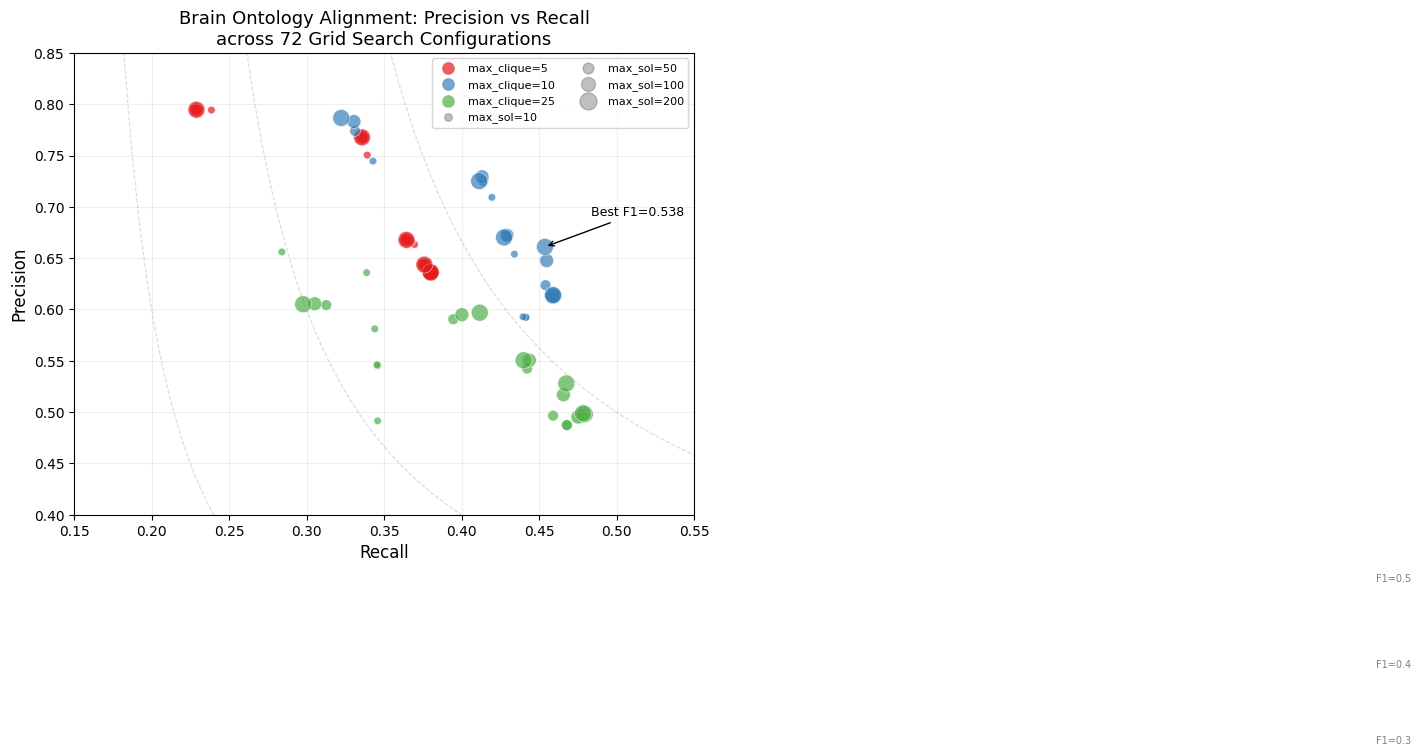

Saved figure2_pr_scatter.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {5: "#e41a1c", 10: "#377eb8", 25: "#4daf4a"}
size_map = {10: 30, 50: 60, 100: 100, 200: 150}

for clique in CLIQUE_VALS:
    subset = df[df["max_pfacts_per_clique"] == clique]
    sizes = [size_map[s] for s in subset["max_candidate_solutions"]]
    ax.scatter(
        subset["recall"], subset["precision"],
        c=colors[clique], s=sizes, alpha=0.7,
        label=f"max_clique={clique}", edgecolors="white", linewidth=0.5,
    )

# Mark best F1
best = df.loc[df["f1"].idxmax()]
ax.annotate(
    f"Best F1={best['f1']:.3f}",
    xy=(best["recall"], best["precision"]),
    xytext=(best["recall"] + 0.03, best["precision"] + 0.03),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9,
)

# F1 isolines
for f1_val in [0.3, 0.4, 0.5]:
    r_vals = np.linspace(0.01, 0.99, 200)
    p_vals = f1_val * r_vals / (2 * r_vals - f1_val)
    mask = (p_vals > 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], "--", color="gray", alpha=0.3, linewidth=0.8)
    # label at end of isoline
    valid_r = r_vals[mask]
    valid_p = p_vals[mask]
    if len(valid_r) > 0:
        ax.text(valid_r[-1], valid_p[-1], f"F1={f1_val}", fontsize=7, color="gray")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Brain Ontology Alignment: Precision vs Recall\nacross 72 Grid Search Configurations", fontsize=13)
ax.legend(title="Clique size limit", fontsize=9)
ax.set_xlim(0.15, 0.55)
ax.set_ylim(0.4, 0.85)
ax.grid(True, alpha=0.2)

# Size legend
for sol, sz in size_map.items():
    ax.scatter([], [], c="gray", s=sz, label=f"max_sol={sol}", alpha=0.5)
ax.legend(fontsize=8, loc="upper right", ncol=2)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure2_pr_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure2_pr_scatter.png")

## Figure 3: F1 Heatmaps by Clique Size

/var/folders/nc/m4tx21912kv1b8nk3zzx9plr0000gn/T/ipykernel_14904/692691420.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


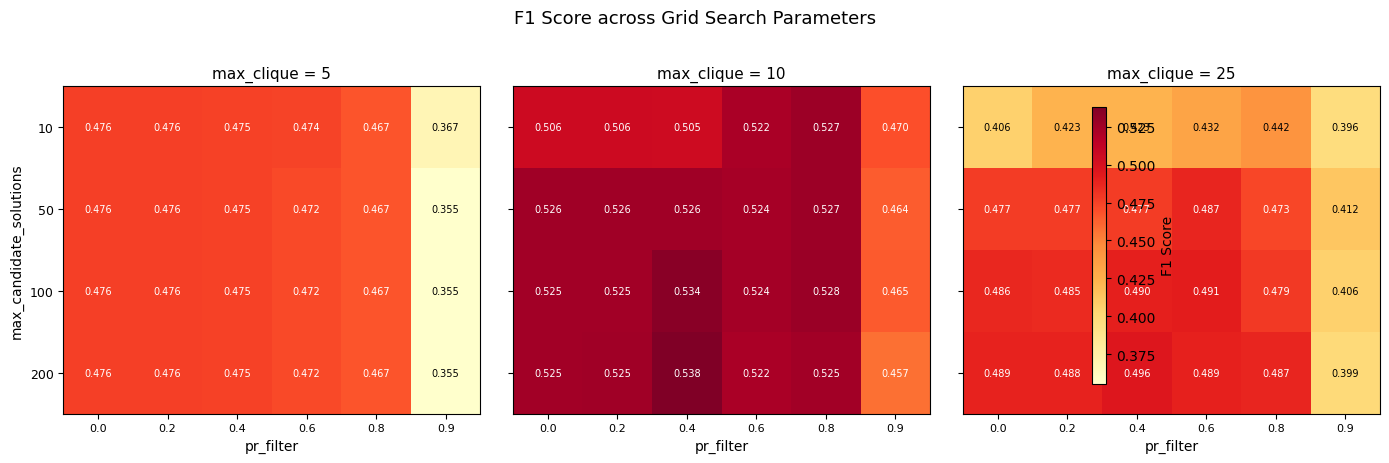

Saved figure3_f1_heatmap.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, clique in enumerate(CLIQUE_VALS):
    ax = axes[idx]
    subset = df[df["max_pfacts_per_clique"] == clique]
    pivot = subset.pivot_table(
        index="max_candidate_solutions", columns="pr_filter", values="f1",
    )
    # Sort index so smallest is at top
    pivot = pivot.sort_index(ascending=True)

    im = ax.imshow(
        pivot.values, cmap="YlOrRd", aspect="auto",
        vmin=df["f1"].min(), vmax=df["f1"].max(),
    )
    ax.set_xticks(range(len(FILTER_VALS)))
    ax.set_xticklabels([f"{v:.1f}" if v < 1 else f"{v:.2f}" for v in FILTER_VALS], fontsize=8)
    ax.set_yticks(range(len(SOL_VALS)))
    ax.set_yticklabels(SOL_VALS, fontsize=9)
    ax.set_xlabel("pr_filter", fontsize=10)
    if idx == 0:
        ax.set_ylabel("max_candidate_solutions", fontsize=10)
    ax.set_title(f"max_clique = {clique}", fontsize=11)

    # Annotate cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            color = "white" if val > 0.45 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=7, color=color)

fig.colorbar(im, ax=axes, label="F1 Score", shrink=0.8)
fig.suptitle("F1 Score across Grid Search Parameters", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure3_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure3_f1_heatmap.png")

## Figure 4: CL+BTO Prior vs Posterior

In [5]:
# Load the CL+BTO solution
with open(TUTORIAL_DIR / "solution.yaml") as f:
    solution = yaml.safe_load(f)

# Extract EquivalentTo mappings with notable posterior changes
mappings = []
for sp in solution["solved_pfacts"]:
    fact = sp["pfact"]["fact"]
    if fact["fact_type"] != "EquivalentTo":
        continue
    if not sp["truth_value"]:
        continue
    prior = sp["pfact"]["prob"]
    posterior = sp["posterior_prob"]
    # Only include CL-BTO mappings
    sub, obj = fact["sub"], fact["equivalent"]
    if "CL:" in sub and "BTO:" in obj or "BTO:" in sub and "CL:" in obj:
        mappings.append({
            "sub": sub, "obj": obj,
            "prior": prior, "posterior": posterior,
            "change": posterior - prior,
        })

map_df = pd.DataFrame(mappings).sort_values("change", ascending=False)
print(f"Found {len(map_df)} accepted CL-BTO EquivalentTo mappings")
map_df.head(10)

Found 7 accepted CL-BTO EquivalentTo mappings


,sub,obj,prior,posterior,change
0,CL:0000066,BTO:0000414,0.7,0.942308,0.242308
1,CL:0000066,BTO:0000414,0.7,0.942308,0.242308
3,CL:0000182,BTO:0000575,0.7,0.942308,0.242308
4,CL:0000182,BTO:0000575,0.7,0.942308,0.242308
2,CL:0000098,BTO:0004301,0.7,0.700000,0.000000
5,CL:0002327,BTO:0004300,0.7,0.700000,0.000000
6,CL:0002586,BTO:0004910,0.7,0.700000,0.000000


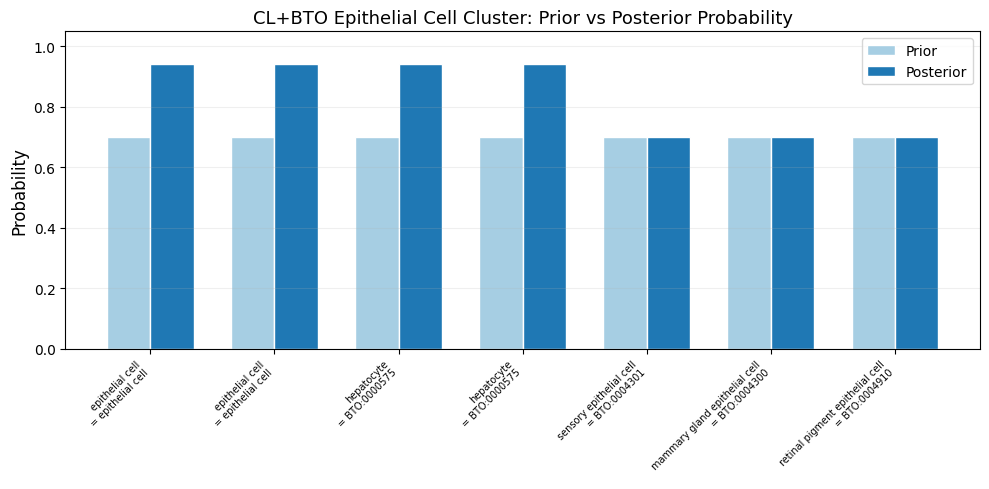

Saved figure4_cl_bto_posteriors.png


In [6]:
# Load labels for display
with open(TUTORIAL_DIR / "epithelial_cluster.yaml") as f:
    cluster_kb = yaml.safe_load(f)
labels = cluster_kb.get("labels", {})

# Select top mappings with biggest posterior change for the figure
top = map_df.head(12).copy()
top["display"] = top.apply(
    lambda r: f"{labels.get(r['sub'], r['sub'])}\n= {labels.get(r['obj'], r['obj'])}",
    axis=1,
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top))
width = 0.35

bars1 = ax.bar(x - width / 2, top["prior"], width, label="Prior", color="#a6cee3", edgecolor="white")
bars2 = ax.bar(x + width / 2, top["posterior"], width, label="Posterior", color="#1f78b4", edgecolor="white")

ax.set_ylabel("Probability", fontsize=12)
ax.set_title("CL+BTO Epithelial Cell Cluster: Prior vs Posterior Probability", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(top["display"], rotation=45, ha="right", fontsize=7)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure4_cl_bto_posteriors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure4_cl_bto_posteriors.png")

## Table 1: Brain Benchmark Dataset Statistics

In [7]:
# Statistics from Prepare.ipynb outputs
ontology_stats = pd.DataFrame([
    {"Ontology": "EMAPA", "Full Name": "Mouse Embryo Anatomy", "Relationships": 407,
     "Source": "OAK/semsql"},
    {"Ontology": "HBA", "Full Name": "Human Brain Atlas", "Relationships": 1837,
     "Source": "OAK/semsql"},
    {"Ontology": "DHBA", "Full Name": "Developing Human Brain Atlas", "Relationships": 3316,
     "Source": "OAK/semsql"},
    {"Ontology": "MBA", "Full Name": "Mouse Brain Atlas", "Relationships": 1326,
     "Source": "OAK/semsql"},
    {"Ontology": "DMBA", "Full Name": "Developing Mouse Brain Atlas", "Relationships": 2691,
     "Source": "OAK/semsql"},
    {"Ontology": "PBA", "Full Name": "Primate Brain Atlas", "Relationships": 258,
     "Source": "OAK/semsql"},
])

print("Table 1: Brain Benchmark Ontology Statistics")
print(f"Total relationships: {ontology_stats['Relationships'].sum()}")
print(f"Ground truth equivalences: 2,688 (from 1,288 UBERON cliques)")
print()
print(ontology_stats.to_markdown(index=False))

Table 1: Brain Benchmark Ontology Statistics
Total relationships: 9835
Ground truth equivalences: 2,688 (from 1,288 UBERON cliques)

| Ontology   | Full Name                    |   Relationships | Source     |
|:-----------|:-----------------------------|----------------:|:-----------|
| EMAPA      | Mouse Embryo Anatomy         |             407 | OAK/semsql |
| HBA        | Human Brain Atlas            |            1837 | OAK/semsql |
| DHBA       | Developing Human Brain Atlas |            3316 | OAK/semsql |
| MBA        | Mouse Brain Atlas            |            1326 | OAK/semsql |
| DMBA       | Developing Mouse Brain Atlas |            2691 | OAK/semsql |
| PBA        | Primate Brain Atlas          |             258 | OAK/semsql |


## Table 2: Top Grid Search Configurations by F1

In [8]:
top5 = df.nlargest(5, "f1")[
    ["config", "max_pfacts_per_clique", "max_candidate_solutions",
     "pr_filter", "precision", "recall", "f1", "tp", "fp", "fn"]
].copy()
top5.columns = [
    "Config", "max_clique", "max_solutions", "pr_filter",
    "Precision", "Recall", "F1", "TP", "FP", "FN",
]

print("Table 2: Top 5 Configurations by F1 Score")
print(top5.to_markdown(index=False, floatfmt=".3f"))

Table 2: Top 5 Configurations by F1 Score
|   Config |   max_clique |   max_solutions |   pr_filter |   Precision |   Recall |    F1 |       TP |      FP |       FN |
|---------:|-------------:|----------------:|------------:|------------:|---------:|------:|---------:|--------:|---------:|
|   44.000 |       10.000 |         200.000 |       0.400 |       0.661 |    0.454 | 0.538 | 1219.000 | 625.000 | 1467.000 |
|   38.000 |       10.000 |         100.000 |       0.400 |       0.648 |    0.455 | 0.534 | 1222.000 | 665.000 | 1464.000 |
|   40.000 |       10.000 |         100.000 |       0.800 |       0.729 |    0.413 | 0.528 | 1110.000 | 412.000 | 1576.000 |
|   28.000 |       10.000 |          10.000 |       0.800 |       0.709 |    0.420 | 0.527 | 1127.000 | 462.000 | 1559.000 |
|   34.000 |       10.000 |          50.000 |       0.800 |       0.725 |    0.414 | 0.527 | 1112.000 | 421.000 | 1574.000 |


## Summary statistics for manuscript text

In [9]:
print("=== Key numbers for manuscript ===")
print(f"Total configs: {len(df)}")
print(f"Best F1: {df['f1'].max():.3f} (config {df.loc[df['f1'].idxmax(), 'config']})")
print(f"  Precision: {df.loc[df['f1'].idxmax(), 'precision']:.3f}")
print(f"  Recall: {df.loc[df['f1'].idxmax(), 'recall']:.3f}")
print(f"Best Precision: {df['precision'].max():.3f}")
print(f"Best Recall: {df['recall'].max():.3f}")
print(f"F1 range: {df['f1'].min():.3f} - {df['f1'].max():.3f}")
print(f"Precision range: {df['precision'].min():.3f} - {df['precision'].max():.3f}")
print(f"Recall range: {df['recall'].min():.3f} - {df['recall'].max():.3f}")
print()
print("=== By max_pfacts_per_clique ===")
for c in CLIQUE_VALS:
    sub = df[df["max_pfacts_per_clique"] == c]
    print(f"  clique={c}: F1 mean={sub['f1'].mean():.3f}, max={sub['f1'].max():.3f}")
print()
print("=== By pr_filter ===")
for fv in FILTER_VALS:
    sub = df[df["pr_filter"] == fv]
    print(f"  filter={fv}: P mean={sub['precision'].mean():.3f}, R mean={sub['recall'].mean():.3f}, F1 mean={sub['f1'].mean():.3f}")

=== Key numbers for manuscript ===
Total configs: 72
Best F1: 0.538 (config 44)
  Precision: 0.661
  Recall: 0.454
Best Precision: 0.795
Best Recall: 0.480
F1 range: 0.355 - 0.538
Precision range: 0.487 - 0.795
Recall range: 0.229 - 0.480

=== By max_pfacts_per_clique ===
  clique=5: F1 mean=0.454, max=0.476
  clique=10: F1 mean=0.513, max=0.538
  clique=25: F1 mean=0.459, max=0.496

=== By pr_filter ===
  filter=0.0: P mean=0.579, R mean=0.426, F1 mean=0.487
  filter=0.2: P mean=0.584, R mean=0.426, F1 mean=0.488
  filter=0.4: P mean=0.601, R mean=0.420, F1 mean=0.491
  filter=0.6: P mean=0.630, R mean=0.404, F1 mean=0.490
  filter=0.8: P mean=0.697, R mean=0.379, F1 mean=0.488
  filter=0.95: P mean=0.728, R mean=0.288, F1 mean=0.409
